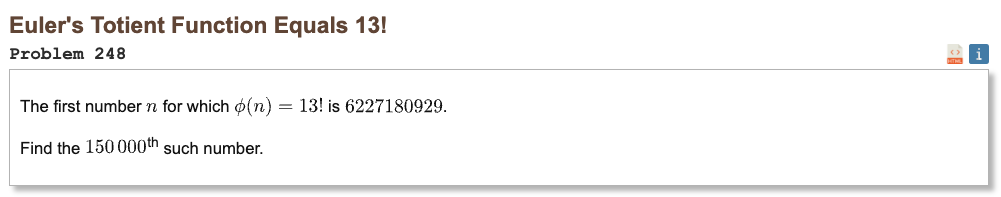

## Initial approach

* start with 13! and break it into prime factors so you know all numbers that can divide it
* remember that the totient of a number is built from each prime part separately, so each prime you use in n must contribute a piece that fits perfectly into 13!
* a prime p can only appear in n if p minus 1 fits inside 13!, so you first find all primes that satisfy this rule
* build n step by step using these allowed primes, always moving forward in order so you do not count the same combination twice
* for each chosen prime, try different powers of it, but only if its contribution still divides what is left of 13!
* each time you use a prime power, shrink the remaining part of 13! and continue the search from there
* remember results for repeated states because the remaining values are limited, this makes the search much faster
* collect every valid n, sort them from small to large, and pick the 150000th one

In [1]:
from math import factorial, isqrt
from functools import lru_cache

def is_prime(n):
    if n < 2:
        return False
    if n % 2 == 0:
        return n == 2
    for i in range(3, isqrt(n) + 1, 2):
        if n % i == 0:
            return False
    return True

def factorize(n):
    f = {}
    d = 2
    while d * d <= n:
        while n % d == 0:
            f[d] = f.get(d, 0) + 1
            n //= d
        d += 1
    if n > 1:
        f[n] = f.get(n, 0) + 1
    return f

def divisors(f):
    divs = [1]
    for p, e in f.items():
        new = []
        for d in divs:
            val = 1
            for _ in range(e + 1):
                new.append(d * val)
                val *= p
        divs = new
    return divs

def solve():
    m = factorial(13)
    pf = factorize(m)
    divs = set(divisors(pf))

    primes = sorted(d + 1 for d in divs if is_prime(d + 1))

    @lru_cache(None)
    def build(i, r):
        if r == 1:
            return [1]
        res = []
        for j in range(i, len(primes)):
            p = primes[j]
            if r % (p - 1) != 0:
                continue
            rem = r // (p - 1)
            power = 1
            while rem % power == 0:
                for sub in build(j + 1, rem // power):
                    res.append(sub * p * power)
                power *= p
        return res

    all_n = sorted(build(0, m))
    result = all_n[150000 - 1]
    print("Result:", result)

if __name__ == "__main__":
    solve()

Result: 23507044290
